# Road Traffic Accident Severity Prediction

Predicts `Accident_severity` (Slight/Serious/Fatal Injury) using a Random Forest classifier.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

## Load & Inspect Data

In [2]:
df = pd.read_csv("RTA Dataset.csv")
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [4]:
missing_percentages = df.isnull().sum() / len(df) * 100
missing_percentages.sort_values(ascending=False).head(16)

Defect_of_vehicle          35.945112
Service_year_of_vehicle    31.893472
Work_of_casuality          25.966223
Fitness_of_casuality       21.394933
Type_of_vehicle             7.713543
Types_of_Junction           7.202014
Driving_experience          6.731082
Educational_level           6.016564
Vehicle_driver_relation     4.701202
Owner_of_vehicle            3.913608
Lanes_or_Medians            3.126015
Vehicle_movement            2.500812
Area_accident_occured       1.940565
Road_surface_type           1.396557
Type_of_collision           1.258525
Road_allignment             1.152972
dtype: float64

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


## Clean Data

Mode-impute the 16 columns with missing values, and parse `Time` into a usable format.

In [6]:
columns_to_impute = [
    'Defect_of_vehicle', 'Service_year_of_vehicle', 'Work_of_casuality',
    'Fitness_of_casuality', 'Type_of_vehicle', 'Types_of_Junction',
    'Driving_experience', 'Educational_level', 'Vehicle_driver_relation',
    'Owner_of_vehicle', 'Lanes_or_Medians', 'Vehicle_movement',
    'Area_accident_occured', 'Road_surface_type', 'Type_of_collision',
    'Road_allignment'
]
for column in columns_to_impute:
    df[column] = df[column].fillna(df[column].mode()[0])

df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time

`Casualty_severity` is dropped here — it's a near-duplicate of the target (`Accident_severity`) and causes data leakage if used as a feature.

In [7]:
df = df.drop(columns=['Casualty_severity'])

## Prepare Features & Target

In [8]:
X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

print("Class distribution:")
print(y.value_counts(normalize=True) * 100)

Class distribution:
Slight Injury     84.564794
Serious Injury    14.152322
Fatal injury       1.282884
Name: Accident_severity, dtype: float64


One-hot encode categorical columns and convert `Time` to seconds-from-midnight.

In [9]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Time')
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

def time_to_seconds(t):
    if pd.isna(t):
        return np.nan
    return t.hour * 3600 + t.minute * 60 + t.second

X_encoded['Time_in_seconds'] = X_encoded['Time'].apply(time_to_seconds)
X_encoded['Time_in_seconds'] = X_encoded['Time_in_seconds'].fillna(X_encoded['Time_in_seconds'].mode()[0])
X_encoded = X_encoded.drop('Time', axis=1)

X_encoded.shape

(12316, 176)

## Exploratory Data Analysis

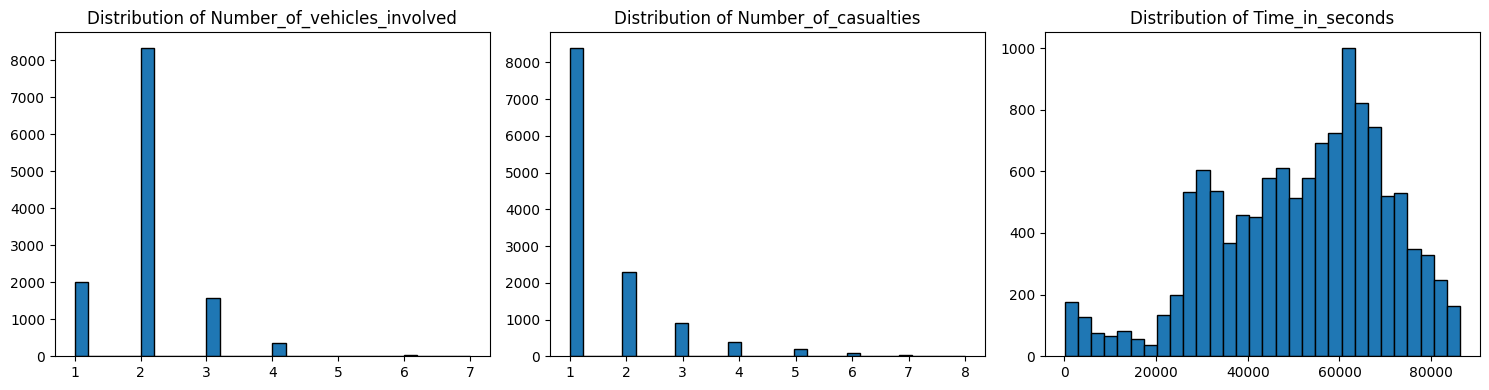

In [10]:
numerical_features = ['Number_of_vehicles_involved', 'Number_of_casualties', 'Time_in_seconds']

plt.figure(figsize=(15, 4))
for i, col in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    plt.hist(X_encoded[col], bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

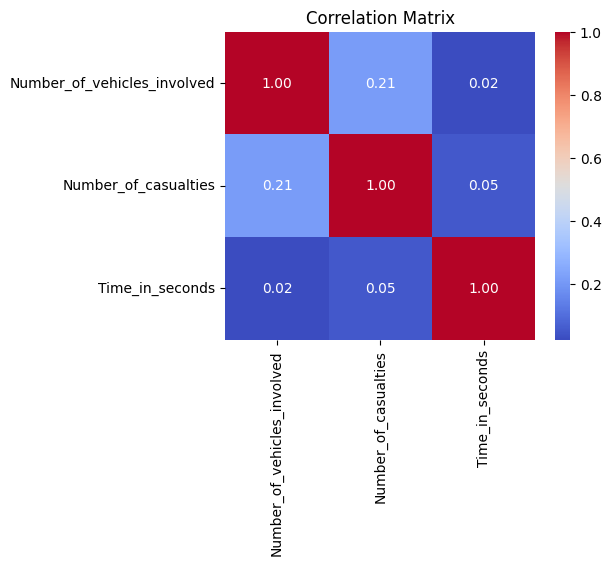

In [11]:
correlation_matrix = X_encoded[numerical_features].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Train/Test Split & SMOTE

Split **before** resampling so the test set reflects the real class distribution and isn't contaminated by synthetic samples derived from what becomes test data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Train shape after SMOTE:", X_train_resampled.shape)
print("Test shape (untouched):", X_test.shape)

Train shape after SMOTE: (24993, 176)
Test shape (untouched): (2464, 176)


## Train Random Forest

In [13]:
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_resampled, y_train_resampled)
y_pred = rf_classifier.predict(X_test)

## Evaluate

Plain accuracy is misleading given the class imbalance (always predicting "Slight Injury" gets ~84.6%), so precision/recall/F1 per class and a confusion matrix are reported too.

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8397

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        31
Serious Injury       0.31      0.04      0.07       349
 Slight Injury       0.85      0.99      0.91      2084

      accuracy                           0.84      2464
     macro avg       0.39      0.34      0.33      2464
  weighted avg       0.76      0.84      0.78      2464



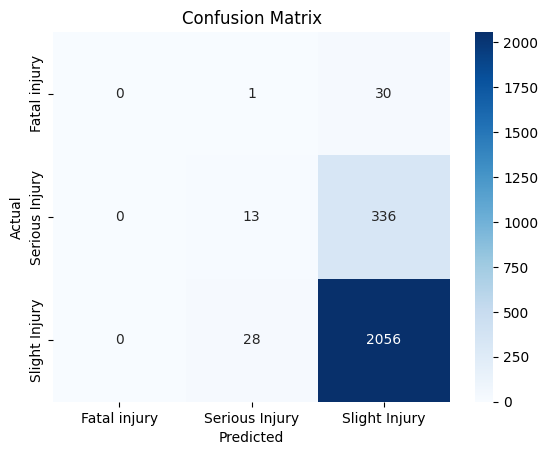

In [15]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Feature Importance

In [16]:
feature_importances = pd.Series(rf_classifier.feature_importances_, index=X_encoded.columns)
top_10_features = feature_importances.nlargest(10)
top_10_features

Time_in_seconds                                                      0.100453
Number_of_casualties                                                 0.066596
Number_of_vehicles_involved                                          0.042449
Light_conditions_Daylight                                            0.024955
Area_accident_occured_Other                                          0.021881
Type_of_collision_Vehicle with vehicle collision                     0.021403
Vehicle_movement_Going straight                                      0.020406
Lanes_or_Medians_Two-way (divided with broken lines road marking)    0.020225
Driving_experience_5-10yr                                            0.019366
Educational_level_Junior high school                                 0.019187
dtype: float64

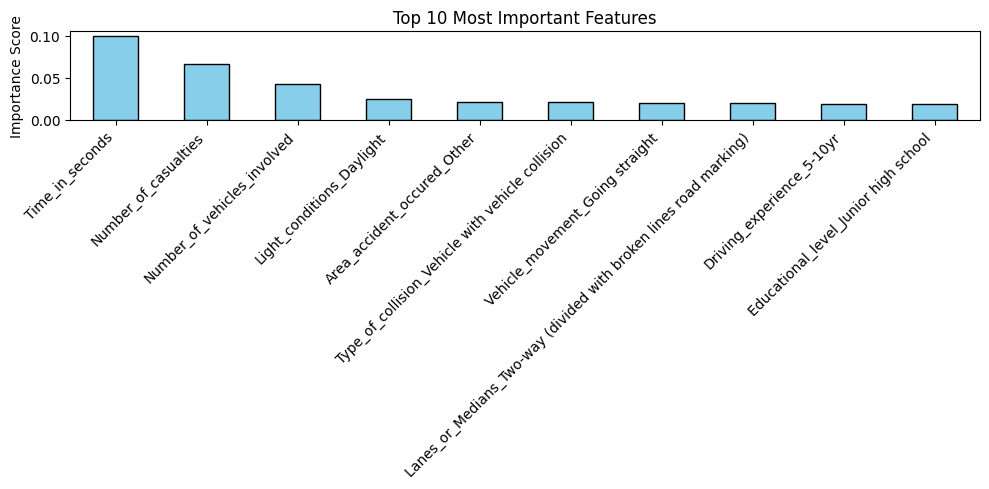

In [17]:
plt.figure(figsize=(10, 5))
top_10_features.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Most Important Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary

- Model reaches **84% accuracy**, but that's barely above the majority-class baseline (84.6%) — recall on Serious/Fatal injury is close to zero.
- `Time_in_seconds` and `Number_of_casualties` are the strongest predictors found so far.
- Next steps: class-weighted models, gradient boosting, and richer features to better separate Serious/Fatal cases from Slight.